# Spotify Main Analysis

This notebook is the main working notebook for the presentation.

For this first pass, it does three things:
1. Load and minimally clean the playlist data
2. Summarize stream share by playlist type (`Spotify-owned` vs `User-owned`)
3. Visualize the `owner_stream_share` distribution


In [1]:
from __future__ import annotations

import ast
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="talk")

DATA_PATH_CANDIDATES = [
    Path("playlist_revision_v05.txt"),
    Path("/Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/playlist_revision_v05.txt"),
]

for candidate in DATA_PATH_CANDIDATES:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find playlist_revision_v05.txt")

DATA_DIR = DATA_PATH.parent
FIGURES_DIR = DATA_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

DATA_PATH


PosixPath('/Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/playlist_revision_v05.txt')

In [2]:
def parse_tokens(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return []


raw_df = pd.read_csv(DATA_PATH, sep="\t")
df = raw_df.drop_duplicates().copy()

for col in ["genre_1", "genre_2", "genre_3", "mood_1", "mood_2", "mood_3"]:
    if col in df.columns:
        df[col] = df[col].replace("-", np.nan)

if "tokens" in df.columns:
    df["tokens_parsed"] = df["tokens"].apply(parse_tokens)
    df["n_title_tokens"] = df["tokens_parsed"].str.len()

df["is_spotify_owned"] = df["owner"].astype(str).str.lower().eq("spotify")
df["playlist_type"] = np.where(df["is_spotify_owned"], "Spotify-owned", "User-owned")

df["owner_stream_share"] = (
    df["monthly_owner_stream30s"]
    / df["monthly_stream30s"].replace(0, np.nan)
)
df["owner_playlist_count"] = df.groupby("owner")["playlist_uri"].transform("count")
df["recent_track_change"] = df["n_local_tracks"]
df["one_artist"] = (df["n_artists"] == 1).astype(int)
df["non_owner_monthly_stream30s"] = (
    df["monthly_stream30s"] - df["monthly_owner_stream30s"]
).clip(lower=0)
df["log_non_owner_monthly_stream30s"] = np.log1p(df["non_owner_monthly_stream30s"])
df["retention_rate"] = (
    df["mau_both_months"] / df["mau_previous_month"].replace(0, np.nan)
)

print(f"Raw rows: {len(raw_df):,}")
print(f"Deduplicated rows: {len(df):,}")
print(df["playlist_type"].value_counts().to_string())


Raw rows: 427,276
Deduplicated rows: 417,484
playlist_type
User-owned       417085
Spotify-owned       399


## Stream Share Tables

Create two versions of the stream-share summary:
- a simple `2`-category split: `Spotify-owned` vs `User-owned`
- a `3`-segment split: `Spotify-owned`, `User-owned, >50% owner share`, and `Other user-owned`

Each table shows:
- number of playlists
- share of all playlists
- total monthly listening (`monthly_stream30s`)
- share of total monthly listening
- total non-owner monthly listening and its share


Saved 2-category stream-share table to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/stream_share_by_playlist_type.csv


,playlist_count,pct_of_total_playlists,total_monthly_stream30s,stream_share,total_non_owner_monthly_stream30s,non_owner_stream_share,median_owner_stream_share
playlist_type,,,,,,,
User-owned,417085,0.9990,153849901,0.2961,105046056,0.2232,0.5652
Spotify-owned,399,0.0010,365656216,0.7039,365655622,0.7768,0.0000


Saved 3-segment stream-share table to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/stream_share_by_segment.csv


,playlist_count,pct_of_total_playlists,total_monthly_stream30s,stream_share,total_non_owner_monthly_stream30s,non_owner_stream_share,median_owner_stream_share
playlist_segment,,,,,,,
Spotify-owned,399,0.0010,365656216,0.7039,365655622,0.7768,0.0000
User-owned (>50% owner streams),224262,0.5372,49322363,0.0949,5995612,0.0127,0.8470
User-owned (<=50% owner streams),192823,0.4619,104527538,0.2012,99050444,0.2104,0.1622


Saved presentation LaTeX table to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/stream_share_by_segment_presentation.tex
Saved presentation PNG table to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/stream_share_by_segment_presentation.png


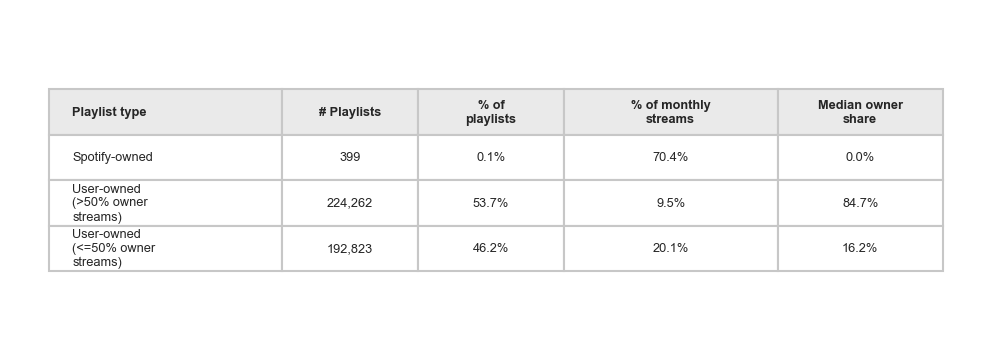

In [3]:
stream_share_by_type = (
    df.groupby("playlist_type", sort=False)
    .agg(
        playlist_count=("playlist_uri", "size"),
        total_monthly_stream30s=("monthly_stream30s", "sum"),
        total_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "sum"),
        median_owner_stream_share=("owner_stream_share", "median"),
    )
)

stream_share_by_type["pct_of_total_playlists"] = (
    stream_share_by_type["playlist_count"] / len(df)
)
stream_share_by_type["stream_share"] = (
    stream_share_by_type["total_monthly_stream30s"]
    / stream_share_by_type["total_monthly_stream30s"].sum()
)
stream_share_by_type["non_owner_stream_share"] = (
    stream_share_by_type["total_non_owner_monthly_stream30s"]
    / stream_share_by_type["total_non_owner_monthly_stream30s"].sum()
)

stream_share_by_type = stream_share_by_type[
    [
        "playlist_count",
        "pct_of_total_playlists",
        "total_monthly_stream30s",
        "stream_share",
        "total_non_owner_monthly_stream30s",
        "non_owner_stream_share",
        "median_owner_stream_share",
    ]
]

stream_share_by_type_csv_path = FIGURES_DIR / "stream_share_by_playlist_type.csv"
stream_share_by_type.to_csv(stream_share_by_type_csv_path, index_label="playlist_type")
print(f"Saved 2-category stream-share table to {stream_share_by_type_csv_path}")
display(stream_share_by_type)

df["playlist_segment"] = np.select(
    [
        df["is_spotify_owned"],
        (~df["is_spotify_owned"]) & (df["owner_stream_share"] > 0.5),
    ],
    [
        "Spotify-owned",
        "User-owned (>50% owner streams)",
    ],
    default="User-owned (<=50% owner streams)",
)

segment_order = [
    "Spotify-owned",
    "User-owned (>50% owner streams)",
    "User-owned (<=50% owner streams)",
]
df["playlist_segment"] = pd.Categorical(df["playlist_segment"], categories=segment_order, ordered=True)

stream_share_by_segment = (
    df.groupby("playlist_segment", sort=False, observed=False)
    .agg(
        playlist_count=("playlist_uri", "size"),
        total_monthly_stream30s=("monthly_stream30s", "sum"),
        total_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "sum"),
        median_owner_stream_share=("owner_stream_share", "median"),
    )
)

stream_share_by_segment["pct_of_total_playlists"] = (
    stream_share_by_segment["playlist_count"] / len(df)
)
stream_share_by_segment["stream_share"] = (
    stream_share_by_segment["total_monthly_stream30s"]
    / stream_share_by_segment["total_monthly_stream30s"].sum()
)
stream_share_by_segment["non_owner_stream_share"] = (
    stream_share_by_segment["total_non_owner_monthly_stream30s"]
    / stream_share_by_segment["total_non_owner_monthly_stream30s"].sum()
)

stream_share_by_segment = stream_share_by_segment[
    [
        "playlist_count",
        "pct_of_total_playlists",
        "total_monthly_stream30s",
        "stream_share",
        "total_non_owner_monthly_stream30s",
        "non_owner_stream_share",
        "median_owner_stream_share",
    ]
]
stream_share_by_segment = stream_share_by_segment.reindex(segment_order)

stream_share_by_segment_csv_path = FIGURES_DIR / "stream_share_by_segment.csv"
stream_share_by_segment.to_csv(stream_share_by_segment_csv_path, index_label="playlist_segment")
print(f"Saved 3-segment stream-share table to {stream_share_by_segment_csv_path}")

display(stream_share_by_segment)

segment_table_present = stream_share_by_segment[
    [
        "playlist_count",
        "pct_of_total_playlists",
        "stream_share",
        "median_owner_stream_share",
    ]
].rename(
    columns={
        "playlist_count": "# Playlists",
        "pct_of_total_playlists": r"\% of playlists",
        "stream_share": r"\% of monthly streams",
        "median_owner_stream_share": "Median owner stream share",
    }
)
segment_table_present.index.name = "Playlist type"

segment_table_latex = segment_table_present.reset_index().copy()
segment_table_latex["# Playlists"] = segment_table_latex["# Playlists"].map(lambda x: f"{x:,.0f}")
segment_table_latex[r"\% of playlists"] = segment_table_latex[r"\% of playlists"].map(lambda x: f"{100 * x:.1f}\\%")
segment_table_latex[r"\% of monthly streams"] = segment_table_latex[r"\% of monthly streams"].map(lambda x: f"{100 * x:.1f}\\%")
segment_table_latex["Median owner stream share"] = segment_table_latex["Median owner stream share"].map(lambda x: f"{100 * x:.1f}\\%")

segment_table_latex_path = FIGURES_DIR / "stream_share_by_segment_presentation.tex"
segment_table_latex_text = segment_table_latex.to_latex(index=False, escape=False, column_format="lrrrr")
segment_table_latex_path.write_text(segment_table_latex_text)
print(f"Saved presentation LaTeX table to {segment_table_latex_path}")

segment_table_png = segment_table_present.reset_index().rename(
    columns={
        r"\% of playlists": "% of\nplaylists",
        r"\% of monthly streams": "% of monthly\nstreams",
        "Median owner stream share": "Median owner\nshare",
    }
).copy()
segment_table_png["Playlist type"] = segment_table_png["Playlist type"].replace(
    {
        "User-owned (>50% owner streams)": "User-owned\n(>50% owner\nstreams)",
        "User-owned (<=50% owner streams)": "User-owned\n(<=50% owner\nstreams)",
    }
)
segment_table_png["# Playlists"] = segment_table_png["# Playlists"].map(lambda x: f"{x:,.0f}")
segment_table_png["% of\nplaylists"] = segment_table_png["% of\nplaylists"].map(lambda x: f"{100 * x:.1f}%")
segment_table_png["% of monthly\nstreams"] = segment_table_png["% of monthly\nstreams"].map(lambda x: f"{100 * x:.1f}%")
segment_table_png["Median owner\nshare"] = segment_table_png["Median owner\nshare"].map(lambda x: f"{100 * x:.1f}%")

fig_table, ax_table = plt.subplots(figsize=(9.8, 3.5), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=segment_table_png.values,
    colLabels=segment_table_png.columns,
    loc="center",
    cellLoc="center",
    colWidths=[0.24, 0.14, 0.15, 0.22, 0.17],
)
table.auto_set_font_size(False)
table.set_fontsize(9.2)
table.scale(1, 2.15)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#c7c7c7")
    if row == 0:
        cell.set_facecolor("#eaeaea")
        cell.set_text_props(weight="bold")
    if col == 0:
        cell.set_text_props(ha="left")

segment_table_png_path = FIGURES_DIR / "stream_share_by_segment_presentation.png"
fig_table.savefig(segment_table_png_path, dpi=220, bbox_inches="tight", facecolor="white")
print(f"Saved presentation PNG table to {segment_table_png_path}")
plt.show()


## Segment Profiles

In [ ]:
segment_profile_df = df.copy()
segment_profile_df["segment"] = np.select(
    [
        segment_profile_df["playlist_type"].eq("Spotify-owned"),
        segment_profile_df["playlist_type"].eq("User-owned") & (segment_profile_df["owner_stream_share"] > 0.5),
    ],
    [
        "Spotify-owned",
        "User-owned (>50% owner streams)",
    ],
    default="User-owned (<=50% owner streams)",
)

segment_order = [
    "Spotify-owned",
    "User-owned (>50% owner streams)",
    "User-owned (<=50% owner streams)",
]

segment_profile_summary_df = (
    segment_profile_df.groupby("segment", observed=False)
    .agg(
        playlist_count=("playlist_uri", "size"),
        pct_of_total_playlists=("playlist_uri", lambda x: len(x) / len(segment_profile_df)),
        median_monthly_stream30s=("monthly_stream30s", "median"),
        mean_monthly_stream30s=("monthly_stream30s", "mean"),
        median_n_tracks=("n_tracks", "median"),
        mean_n_tracks=("n_tracks", "mean"),
        median_n_artists=("n_artists", "median"),
        mean_n_artists=("n_artists", "mean"),
        median_n_albums=("n_albums", "median"),
        mean_n_albums=("n_albums", "mean"),
        playlists_with_prev_month_mau=("mau_previous_month", lambda x: (x > 0).sum()),
        median_retention_rate=("retention_rate", "median"),
        mean_retention_rate=("retention_rate", "mean"),
        total_mau_previous_month=("mau_previous_month", "sum"),
        total_mau_both_months=("mau_both_months", "sum"),
    )
    .reset_index()
)
segment_profile_summary_df["pct_retention_eligible"] = (
    segment_profile_summary_df["playlists_with_prev_month_mau"]
    / segment_profile_summary_df["playlist_count"].replace(0, np.nan)
)
segment_profile_summary_df["aggregate_retention_rate"] = (
    segment_profile_summary_df["total_mau_both_months"]
    / segment_profile_summary_df["total_mau_previous_month"].replace(0, np.nan)
)
segment_profile_summary_df["segment"] = pd.Categorical(
    segment_profile_summary_df["segment"],
    categories=segment_order,
    ordered=True,
)
segment_profile_summary_df = segment_profile_summary_df.sort_values("segment").reset_index(drop=True)

segment_profile_summary_path = FIGURES_DIR / "segment_profile_summary.csv"
segment_profile_summary_df.to_csv(segment_profile_summary_path, index=False)

segment_profile_presentation_df = segment_profile_summary_df.rename(
    columns={
        "segment": "Segment",
        "playlist_count": "# Playlists",
        "pct_of_total_playlists": "% of playlists",
        "median_monthly_stream30s": "Median monthly 30s streams",
        "mean_monthly_stream30s": "Mean monthly 30s streams",
        "median_n_tracks": "Median # tracks",
        "mean_n_tracks": "Mean # tracks",
        "median_n_artists": "Median # artists",
        "mean_n_artists": "Mean # artists",
        "median_n_albums": "Median # albums",
        "mean_n_albums": "Mean # albums",
        "pct_retention_eligible": "% with previous-month MAU",
        "median_retention_rate": "Median continuity rate",
        "aggregate_retention_rate": "Aggregate continuity rate",
    }
)
segment_profile_presentation_df = segment_profile_presentation_df[
    [
        "Segment",
        "# Playlists",
        "% of playlists",
        "Median monthly 30s streams",
        "Mean monthly 30s streams",
        "Median # tracks",
        "Mean # tracks",
        "Median # artists",
        "Mean # artists",
        "Median # albums",
        "Mean # albums",
        "% with previous-month MAU",
        "Median continuity rate",
        "Aggregate continuity rate",
    ]
]
segment_profile_presentation_path = FIGURES_DIR / "segment_profile_summary_presentation.csv"
segment_profile_presentation_df.to_csv(segment_profile_presentation_path, index=False)

print(f"Saved segment profile summary to {segment_profile_summary_path}")
print(f"Saved presentation-friendly segment profile summary to {segment_profile_presentation_path}")

display(segment_profile_presentation_df)


## Reach x Intensity 2x2

In [ ]:

user_owned_2x2_df = df.loc[df["playlist_type"] == "User-owned"].copy()
user_owned_2x2_df["monthly_stream30s_per_mau"] = (
    user_owned_2x2_df["monthly_stream30s"] / user_owned_2x2_df["mau"].replace(0, np.nan)
)

reach_cut = user_owned_2x2_df["non_owner_monthly_stream30s"].median()
intensity_cut = user_owned_2x2_df["monthly_stream30s_per_mau"].median()

user_owned_2x2_df["reach_group"] = np.where(
    user_owned_2x2_df["non_owner_monthly_stream30s"] >= reach_cut,
    "High reach",
    "Low reach",
)
user_owned_2x2_df["intensity_group"] = np.where(
    user_owned_2x2_df["monthly_stream30s_per_mau"] >= intensity_cut,
    "High intensity",
    "Low intensity",
)

reach_order = ["High reach", "Low reach"]
intensity_order = ["High intensity", "Low intensity"]

reach_intensity_summary_df = (
    user_owned_2x2_df.groupby(["reach_group", "intensity_group"], observed=False)
    .agg(
        playlist_count=("playlist_uri", "size"),
        pct_of_user_owned=("playlist_uri", lambda x: len(x) / len(user_owned_2x2_df)),
        median_reach=("non_owner_monthly_stream30s", "median"),
        median_intensity=("monthly_stream30s_per_mau", "median"),
        median_owner_stream_share=("owner_stream_share", "median"),
        median_retention_rate=("retention_rate", "median"),
    )
    .reset_index()
)
reach_intensity_summary_df["reach_group"] = pd.Categorical(
    reach_intensity_summary_df["reach_group"],
    categories=reach_order,
    ordered=True,
)
reach_intensity_summary_df["intensity_group"] = pd.Categorical(
    reach_intensity_summary_df["intensity_group"],
    categories=intensity_order,
    ordered=True,
)
reach_intensity_summary_df = reach_intensity_summary_df.sort_values(
    ["reach_group", "intensity_group"]
).reset_index(drop=True)
reach_intensity_summary_df["reach_cut"] = reach_cut
reach_intensity_summary_df["intensity_cut"] = intensity_cut

reach_intensity_summary_path = FIGURES_DIR / "user_owned_reach_intensity_2x2.csv"
reach_intensity_summary_df.to_csv(reach_intensity_summary_path, index=False)

reach_intensity_presentation_df = reach_intensity_summary_df.rename(
    columns={
        "reach_group": "Reach group",
        "intensity_group": "Intensity group",
        "playlist_count": "# Playlists",
        "pct_of_user_owned": "% of user-owned playlists",
        "median_reach": "Median reach",
        "median_intensity": "Median intensity",
        "median_owner_stream_share": "Median owner stream share",
        "median_retention_rate": "Median continuity rate",
        "reach_cut": "Reach cut",
        "intensity_cut": "Intensity cut",
    }
)
reach_intensity_presentation_path = FIGURES_DIR / "user_owned_reach_intensity_2x2_presentation.csv"
reach_intensity_presentation_df.to_csv(reach_intensity_presentation_path, index=False)

heatmap_values = (
    reach_intensity_summary_df.pivot(index="reach_group", columns="intensity_group", values="pct_of_user_owned")
    .reindex(index=reach_order, columns=intensity_order)
)
count_values = (
    reach_intensity_summary_df.pivot(index="reach_group", columns="intensity_group", values="playlist_count")
    .reindex(index=reach_order, columns=intensity_order)
)
annot = heatmap_values.copy().astype(str)
for row in reach_order:
    for col in intensity_order:
        owner_share = reach_intensity_summary_df.loc[(reach_intensity_summary_df["reach_group"] == row) & (reach_intensity_summary_df["intensity_group"] == col), "median_owner_stream_share"].iloc[0]
        annot.loc[row, col] = f"{int(count_values.loc[row, col]):,}\n({heatmap_values.loc[row, col]:.1%})\nOwner: {owner_share:.0%}"

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
sns.heatmap(
    heatmap_values,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"format": PercentFormatter(1.0), "label": "% of user-owned playlists"},
    ax=ax,
)
ax.set_title("User-owned playlists: reach vs intensity segmentation")
ax.set_xlabel(f"Intensity split at median = {intensity_cut:,.1f}")
ax.set_ylabel(f"Reach split at median = {reach_cut:,.0f}")
heatmap_path = FIGURES_DIR / "user_owned_reach_intensity_2x2_heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved reach-intensity 2x2 summary to {reach_intensity_summary_path}")
print(f"Saved presentation-friendly 2x2 summary to {reach_intensity_presentation_path}")
print(f"Saved reach-intensity heatmap to {heatmap_path}")

display(reach_intensity_summary_df)


## Non-owner Monthly 30s Streams Distribution

Visualize the main reach metric:
- raw `non_owner_monthly_stream30s`
- `log1p(non_owner_monthly_stream30s)`

We use `log1p` rather than `log` because some playlists have `0` non-owner monthly 30-second streams.


Saved raw non-owner-stream distribution to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/non_owner_monthly_stream30s_distribution_raw_p99.png


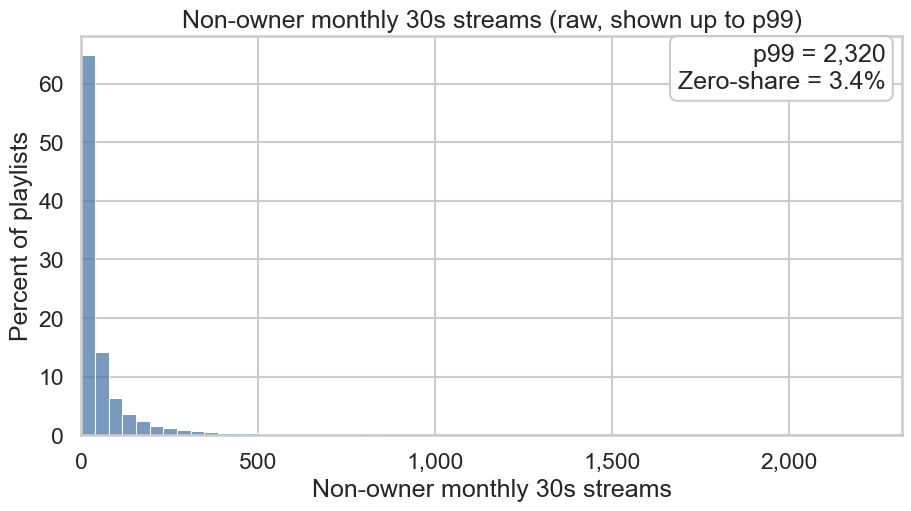

Saved log-transformed non-owner-stream distribution to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/non_owner_monthly_stream30s_distribution_log1p.png


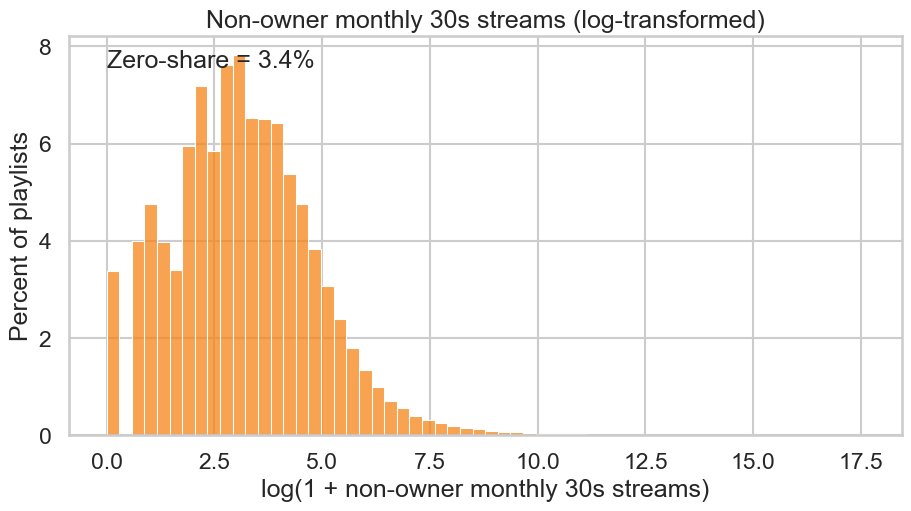

In [4]:
non_owner_streams = df["non_owner_monthly_stream30s"].copy()
non_owner_streams_log1p = np.log1p(non_owner_streams)
non_owner_streams_p99 = float(non_owner_streams.quantile(0.99))
zero_non_owner_share = float((non_owner_streams == 0).mean())

fig_raw, ax_raw = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.histplot(
    non_owner_streams,
    bins=60,
    binrange=(0, non_owner_streams_p99),
    stat="percent",
    color="#4c78a8",
    ax=ax_raw,
)
ax_raw.set_xlim(0, non_owner_streams_p99)
ax_raw.set_title("Non-owner monthly 30s streams (raw, shown up to p99)")
ax_raw.set_xlabel("Non-owner monthly 30s streams")
ax_raw.set_ylabel("Percent of playlists")
ax_raw.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax_raw.text(
    0.98,
    0.98,
    f"p99 = {non_owner_streams_p99:,.0f}\nZero-share = {zero_non_owner_share:.1%}",
    transform=ax_raw.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="#c7c7c7"),
)

raw_non_owner_plot_path = FIGURES_DIR / "non_owner_monthly_stream30s_distribution_raw_p99.png"
fig_raw.savefig(raw_non_owner_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved raw non-owner-stream distribution to {raw_non_owner_plot_path}")
plt.show()

fig_log, ax_log = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.histplot(
    non_owner_streams_log1p,
    bins=60,
    stat="percent",
    color="#f58518",
    ax=ax_log,
)
ax_log.set_title("Non-owner monthly 30s streams (log-transformed)")
ax_log.set_xlabel("log(1 + non-owner monthly 30s streams)")
ax_log.set_ylabel("Percent of playlists")
ax_log.xaxis.set_major_formatter(StrMethodFormatter("{x:,.1f}"))
ax_log.text(
    non_owner_streams_log1p.quantile(0.02),
    ax_log.get_ylim()[1] * 0.92,
    f"Zero-share = {zero_non_owner_share:.1%}",
)

log_non_owner_plot_path = FIGURES_DIR / "non_owner_monthly_stream30s_distribution_log1p.png"
fig_log.savefig(log_non_owner_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved log-transformed non-owner-stream distribution to {log_non_owner_plot_path}")
plt.show()


## Structural Correlations With The Main Success Metric

Compute simple Spearman correlations between `non_owner_monthly_stream30s` and the main structural playlist features.

I report `Spotify-owned` and `User-owned` playlists separately because they operate under very different conditions.

Spearman is a good fit here because the success metric is extremely skewed and we care more about monotonic relationships than linearity on the raw scale.


In [5]:
def spearman_correlation_table(data, target, features, feature_labels=None):
    rows = []
    for feature in features:
        sub = data[[feature, target]].dropna()
        if sub.empty or sub[feature].nunique() < 2 or sub[target].nunique() < 2:
            rho = np.nan
        else:
            rho = sub[feature].corr(sub[target], method="spearman")
        rows.append(
            {
                "feature": feature,
                "feature_label": feature_labels.get(feature, feature) if feature_labels else feature,
                "spearman_rho": rho,
                "n": len(sub),
            }
        )
    out = pd.DataFrame(rows)
    return out.sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


feature_labels = {
    "n_tracks": "# tracks",
    "n_artists": "# artists",
    "n_albums": "# albums",
    "recent_track_change": "Recent track change",
    "owner_playlist_count": "Owner playlist count",
    "n_title_tokens": "# title tokens",
    "one_artist": "One artist playlist",
}

spotify_corr_features = [
    "n_tracks",
    "n_artists",
    "n_albums",
    "recent_track_change",
    "n_title_tokens",
    "one_artist",
]
user_corr_features = spotify_corr_features + ["owner_playlist_count"]

spotify_corr_df = spearman_correlation_table(
    df.loc[df["playlist_type"] == "Spotify-owned"].copy(),
    target="non_owner_monthly_stream30s",
    features=spotify_corr_features,
    feature_labels=feature_labels,
)
user_corr_df = spearman_correlation_table(
    df.loc[df["playlist_type"] == "User-owned"].copy(),
    target="non_owner_monthly_stream30s",
    features=user_corr_features,
    feature_labels=feature_labels,
)

spotify_corr_path = FIGURES_DIR / "success_correlations_spotify_owned.csv"
user_corr_path = FIGURES_DIR / "success_correlations_user_owned.csv"
spotify_corr_df.to_csv(spotify_corr_path, index=False)
user_corr_df.to_csv(user_corr_path, index=False)
print(f"Saved Spotify-owned correlations to {spotify_corr_path}")
print(f"Saved User-owned correlations to {user_corr_path}")

combined_corr_df = (
    user_corr_df[["feature_label", "spearman_rho"]]
    .rename(columns={"spearman_rho": "User-owned rho"})
    .merge(
        spotify_corr_df[["feature_label", "spearman_rho"]].rename(columns={"spearman_rho": "Spotify-owned rho"}),
        on="feature_label",
        how="outer",
    )
)

combined_corr_order = [feature_labels[f] for f in user_corr_features]
combined_corr_df["feature_label"] = pd.Categorical(combined_corr_df["feature_label"], categories=combined_corr_order, ordered=True)
combined_corr_df = combined_corr_df.sort_values("feature_label").reset_index(drop=True)

combined_corr_path = FIGURES_DIR / "success_correlations_combined.csv"
combined_corr_df.to_csv(combined_corr_path, index=False)
print(f"Saved combined correlation table to {combined_corr_path}")

display(user_corr_df)
display(spotify_corr_df)
display(combined_corr_df)


Saved Spotify-owned correlations to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/success_correlations_spotify_owned.csv
Saved User-owned correlations to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/success_correlations_user_owned.csv
Saved combined correlation table to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/success_correlations_combined.csv


,feature,feature_label,spearman_rho,n
0,n_tracks,# tracks,0.2403,417085
1,n_albums,# albums,0.1909,417085
2,n_artists,# artists,0.1849,417085
3,one_artist,One artist playlist,-0.1701,417085
4,n_title_tokens,# title tokens,0.1657,417085
5,owner_playlist_count,Owner playlist count,0.0649,417085
6,recent_track_change,Recent track change,0.0573,417085


,feature,feature_label,spearman_rho,n
0,n_tracks,# tracks,0.3998,399
1,n_albums,# albums,0.3886,399
2,n_artists,# artists,0.3790,399
3,one_artist,One artist playlist,0.0762,399
4,recent_track_change,Recent track change,-0.0298,399
5,n_title_tokens,# title tokens,0.0129,399


,feature_label,User-owned rho,Spotify-owned rho
0,# tracks,0.2403,0.3998
1,# artists,0.1849,0.3790
2,# albums,0.1909,0.3886
3,Recent track change,0.0573,-0.0298
4,# title tokens,0.1657,0.0129
5,One artist playlist,-0.1701,0.0762
6,Owner playlist count,0.0649,NaN


## Structural Feature Diagnostics Across Success Metrics

This section focuses on `user-owned playlists` and compares a common set of structural features against three success lenses:

- `non_owner_monthly_stream30s`: broad reach beyond the playlist owner
- `monthly_stream30s / mau`: listening intensity per active user
- `mau_both_months / mau_previous_month`: playlist continuity among eligible playlists

For each feature-metric pair, the notebook saves three diagnostics into `figures/structural_feature_diagnostics/`:

- a simple `hexbin + linear fit` view
- a `binned median` chart
- a `binned mean` chart

I exclude `one_artist` from this loop because it is binary and does not fit the same regression/binning treatment as the count-based structural features.

In [ ]:
from collections import OrderedDict

user_df = df.loc[df["playlist_type"] == "User-owned"].copy()
user_df["monthly_stream30s_per_mau"] = (
    user_df["monthly_stream30s"] / user_df["mau"].replace(0, np.nan)
)

STRUCTURAL_DIAGNOSTICS_DIR = FIGURES_DIR / "structural_feature_diagnostics"
STRUCTURAL_DIAGNOSTICS_DIR.mkdir(exist_ok=True)

structural_feature_specs = OrderedDict(
    {
        "n_tracks": {
            "label": "# tracks",
            "bin_edges": [1, 10, 25, 50, 100, 250, 500, 1000, np.inf],
            "bin_labels": ["1-9", "10-24", "25-49", "50-99", "100-249", "250-499", "500-999", "1000+"],
        },
        "n_artists": {
            "label": "# artists",
            "bin_edges": [1, 5, 10, 25, 50, 100, 250, 500, np.inf],
            "bin_labels": ["1-4", "5-9", "10-24", "25-49", "50-99", "100-249", "250-499", "500+"],
        },
        "n_albums": {
            "label": "# albums",
            "bin_edges": [1, 5, 10, 25, 50, 100, 250, 500, np.inf],
            "bin_labels": ["1-4", "5-9", "10-24", "25-49", "50-99", "100-249", "250-499", "500+"],
        },
        "recent_track_change": {
            "label": "Recent track change",
            "bin_edges": [0, 1, 2, 5, 10, 25, 50, np.inf],
            "bin_labels": ["0", "1", "2-4", "5-9", "10-24", "25-49", "50+"],
        },
        "owner_playlist_count": {
            "label": "Owner playlist count",
            "bin_edges": [1, 2, 3, 5, 10, 25, np.inf],
            "bin_labels": ["1", "2", "3-4", "5-9", "10-24", "25+"],
        },
        "n_title_tokens": {
            "label": "# title tokens",
            "bin_edges": [0, 1, 2, 3, 4, np.inf],
            "bin_labels": ["0", "1", "2", "3", "4+"],
        },
    }
)

success_metric_specs = OrderedDict(
    {
        "non_owner_monthly_stream30s": {
            "label": "Non-owner monthly 30s streams",
            "folder": "non_owner_monthly_stream30s",
            "y_transform": "log1p",
            "plot_color": "#4c78a8",
            "value_kind": "stream",
        },
        "monthly_stream30s_per_mau": {
            "label": "Monthly 30s streams per active user",
            "folder": "monthly_stream30s_per_mau",
            "y_transform": "log1p",
            "plot_color": "#f58518",
            "value_kind": "stream",
        },
        "retention_rate": {
            "label": "Continuity rate",
            "folder": "retention_rate",
            "y_transform": "identity",
            "plot_color": "#54a24b",
            "value_kind": "percent",
        },
    }
)

for metric_spec in success_metric_specs.values():
    (STRUCTURAL_DIAGNOSTICS_DIR / metric_spec["folder"]).mkdir(exist_ok=True)


def transform_series(series, transform):
    if transform == "log1p":
        return np.log1p(series)
    if transform == "identity":
        return series
    raise ValueError(f"Unsupported transform: {transform}")



def transformed_axis_label(metric_label, transform):
    if transform == "log1p":
        return f"log(1 + {metric_label.lower()})"
    return metric_label



def metric_formatter(kind, value):
    if pd.isna(value):
        return "NA"
    if kind == "percent":
        return f"{value:.0%}"
    return f"{value:,.0f}"



def apply_y_axis_format(ax, value_kind):
    if value_kind == "percent":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    else:
        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))



def build_binned_summary(data, feature, feature_spec, metric):
    out = data.copy()
    out["feature_bin"] = pd.cut(
        out[feature],
        bins=feature_spec["bin_edges"],
        labels=feature_spec["bin_labels"],
        include_lowest=True,
        right=False,
    )
    summary = (
        out.groupby("feature_bin", observed=False)
        .agg(
            playlist_count=("playlist_uri", "size"),
            mean_value=(metric, "mean"),
            median_value=(metric, "median"),
            median_feature_value=(feature, "median"),
        )
        .reset_index()
    )
    return summary



def make_hexbin_plot(data, feature, feature_label, metric, metric_spec, output_path):
    x = np.log1p(data[feature])
    y = transform_series(data[metric], metric_spec["y_transform"])
    slope, intercept = np.polyfit(x, y, 1)
    fitted = intercept + slope * x
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    spearman_rho = data[[feature, metric]].corr(method="spearman").iloc[0, 1]

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    hb = ax.hexbin(
        x,
        y,
        gridsize=55,
        mincnt=1,
        bins="log",
        cmap="viridis",
    )
    line_x = np.linspace(float(x.min()), float(x.max()), 200)
    line_y = intercept + slope * line_x
    ax.plot(line_x, line_y, color="#d62728", linewidth=3, label="OLS fit")
    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("Playlists per hexbin (log scale)")
    ax.set_title(f"User-owned playlists: {feature_label.lower()} vs {metric_spec['label'].lower()}")
    ax.set_xlabel(f"log(1 + {feature_label.lower()})")
    ax.set_ylabel(transformed_axis_label(metric_spec["label"], metric_spec["y_transform"]))
    if metric_spec["value_kind"] == "percent":
        ax.set_ylim(0, 1)
        apply_y_axis_format(ax, "percent")
    ax.text(
        0.03,
        0.97,
        f"n = {len(data):,}\nSlope = {slope:.3f}\n$R^2$ = {r2:.3f}\nSpearman = {spearman_rho:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="#c7c7c7"),
    )
    ax.legend(loc="lower right", frameon=True)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    return {
        "n": len(data),
        "slope": float(slope),
        "intercept": float(intercept),
        "r2": float(r2),
        "spearman_rho": float(spearman_rho),
    }



def make_binned_plot(summary, feature_label, metric_spec, stat, output_path):
    column = "median_value" if stat == "median" else "mean_value"
    title_stat = "Median" if stat == "median" else "Average"

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    sns.lineplot(
        data=summary,
        x="feature_bin",
        y=column,
        marker="o",
        linewidth=3,
        color=metric_spec["plot_color"],
        ax=ax,
    )
    ax.set_title(f"{title_stat} {metric_spec['label'].lower()} by {feature_label.lower()} bin")
    ax.set_xlabel(feature_label)
    ax.set_ylabel(f"{title_stat} {metric_spec['label'].lower()}")
    apply_y_axis_format(ax, metric_spec["value_kind"])

    for _, row in summary.iterrows():
        ax.annotate(
            metric_formatter(metric_spec["value_kind"], row[column]),
            (row["feature_bin"], row[column]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=10,
        )

    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


regression_rows = []
binned_rows = []
figure_rows = []

for feature, feature_spec in structural_feature_specs.items():
    feature_label = feature_spec["label"]
    for metric, metric_spec in success_metric_specs.items():
        sub = user_df[["playlist_uri", feature, metric]].dropna().copy()
        sub = sub.loc[sub[feature] >= 0].copy()
        if len(sub) == 0 or sub[feature].nunique() < 2 or sub[metric].nunique() < 2:
            continue

        metric_dir = STRUCTURAL_DIAGNOSTICS_DIR / metric_spec["folder"]
        base_name = f"{feature}__{metric}"
        hexbin_path = metric_dir / f"{base_name}__hexbin_regression.png"
        median_path = metric_dir / f"{base_name}__binned_median.png"
        mean_path = metric_dir / f"{base_name}__binned_mean.png"

        reg_stats = make_hexbin_plot(
            data=sub,
            feature=feature,
            feature_label=feature_label,
            metric=metric,
            metric_spec=metric_spec,
            output_path=hexbin_path,
        )
        regression_rows.append(
            {
                "feature": feature,
                "feature_label": feature_label,
                "success_metric": metric,
                "success_metric_label": metric_spec["label"],
                **reg_stats,
            }
        )

        summary = build_binned_summary(sub, feature, feature_spec, metric)
        summary["feature"] = feature
        summary["feature_label"] = feature_label
        summary["success_metric"] = metric
        summary["success_metric_label"] = metric_spec["label"]
        binned_rows.append(summary)

        make_binned_plot(summary, feature_label, metric_spec, "median", median_path)
        make_binned_plot(summary, feature_label, metric_spec, "mean", mean_path)

        figure_rows.extend(
            [
                {
                    "feature_label": feature_label,
                    "success_metric_label": metric_spec["label"],
                    "plot_type": "hexbin_regression",
                    "path": hexbin_path.relative_to(DATA_DIR).as_posix(),
                },
                {
                    "feature_label": feature_label,
                    "success_metric_label": metric_spec["label"],
                    "plot_type": "binned_median",
                    "path": median_path.relative_to(DATA_DIR).as_posix(),
                },
                {
                    "feature_label": feature_label,
                    "success_metric_label": metric_spec["label"],
                    "plot_type": "binned_mean",
                    "path": mean_path.relative_to(DATA_DIR).as_posix(),
                },
            ]
        )

regression_summary_df = pd.DataFrame(regression_rows).sort_values(
    ["success_metric_label", "r2"], ascending=[True, False]
).reset_index(drop=True)

binned_summary_df = pd.concat(binned_rows, ignore_index=True)
figure_index_df = pd.DataFrame(figure_rows).sort_values(
    ["success_metric_label", "feature_label", "plot_type"]
).reset_index(drop=True)

regression_summary_path = STRUCTURAL_DIAGNOSTICS_DIR / "structural_feature_regression_summary.csv"
binned_summary_path = STRUCTURAL_DIAGNOSTICS_DIR / "structural_feature_binned_summary.csv"
figure_index_path = STRUCTURAL_DIAGNOSTICS_DIR / "structural_feature_figure_index.csv"

regression_summary_df.to_csv(regression_summary_path, index=False)
binned_summary_df.to_csv(binned_summary_path, index=False)
figure_index_df.to_csv(figure_index_path, index=False)

print(f"Saved regression summary to {regression_summary_path}")
print(f"Saved binned summary to {binned_summary_path}")
print(f"Saved figure index to {figure_index_path}")
print(f"Saved {len(figure_index_df):,} diagnostic figures to {STRUCTURAL_DIAGNOSTICS_DIR}")

display(regression_summary_df[["success_metric_label", "feature_label", "n", "spearman_rho", "slope", "r2"]])
display(figure_index_df.head(18))

## Multivariate Structural Model

I fit a simple multivariate linear model on the `user-owned` sample to measure how much variation is jointly explained by the observed structural features.

Predictors:
- `log1p(n_tracks)`
- `log1p(n_artists)`
- `log1p(n_albums)`
- `log1p(recent_track_change)`
- `log1p(owner_playlist_count)`
- `log1p(n_title_tokens)`

Outcomes:
- `log1p(non_owner_monthly_stream30s)` for broad reach
- `log1p(monthly_stream30s / mau)` for per-user intensity
- `mau_both_months / mau_previous_month` for continuity

Because several breadth features are highly correlated, I use this section mainly to summarize `variation explained`, not to make strong causal or coefficient-level claims.

In [ ]:
import statsmodels.api as sm

user_model_df = df.loc[df["playlist_type"] == "User-owned"].copy()
user_model_df["monthly_stream30s_per_mau"] = (
    user_model_df["monthly_stream30s"] / user_model_df["mau"].replace(0, np.nan)
)

model_feature_map = {
    "log_n_tracks": np.log1p(user_model_df["n_tracks"]),
    "log_n_artists": np.log1p(user_model_df["n_artists"]),
    "log_n_albums": np.log1p(user_model_df["n_albums"]),
    "log_recent_track_change": np.log1p(user_model_df["recent_track_change"]),
    "log_owner_playlist_count": np.log1p(user_model_df["owner_playlist_count"]),
    "log_n_title_tokens": np.log1p(user_model_df["n_title_tokens"]),
}
X_structural = pd.DataFrame(model_feature_map)

model_specs = {
    "Broad reach": {
        "outcome": np.log1p(user_model_df["non_owner_monthly_stream30s"]),
        "outcome_label": "log(1 + non-owner monthly 30s streams)",
    },
    "Per-user intensity": {
        "outcome": np.log1p(user_model_df["monthly_stream30s_per_mau"]),
        "outcome_label": "log(1 + monthly 30s streams per active user)",
    },
    "Continuity": {
        "outcome": user_model_df["retention_rate"],
        "outcome_label": "continuity rate",
    },
}

model_summary_rows = []
coefficient_rows = []

for model_name, spec in model_specs.items():
    modeling_df = pd.concat(
        [spec["outcome"].rename("outcome"), X_structural],
        axis=1,
    ).dropna().copy()

    y = modeling_df.pop("outcome")
    X = sm.add_constant(modeling_df, has_constant="add")
    fitted_model = sm.OLS(y, X).fit()

    model_summary_rows.append(
        {
            "model": model_name,
            "outcome_label": spec["outcome_label"],
            "n": len(y),
            "r_squared": fitted_model.rsquared,
            "adj_r_squared": fitted_model.rsquared_adj,
        }
    )

    for term, value in fitted_model.params.drop("const").items():
        coefficient_rows.append(
            {
                "model": model_name,
                "term": term,
                "coefficient": value,
                "abs_coefficient": abs(value),
            }
        )

model_summary_df = pd.DataFrame(model_summary_rows).sort_values("adj_r_squared", ascending=False).reset_index(drop=True)
coefficient_summary_df = pd.DataFrame(coefficient_rows).sort_values(["model", "abs_coefficient"], ascending=[True, False]).reset_index(drop=True)

model_summary_path = FIGURES_DIR / "multivariate_structural_model_summary.csv"
coefficient_summary_path = FIGURES_DIR / "multivariate_structural_model_coefficients.csv"
model_summary_df.to_csv(model_summary_path, index=False)
coefficient_summary_df.to_csv(coefficient_summary_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.barplot(
    data=model_summary_df,
    x="model",
    y="adj_r_squared",
    palette=["#4c78a8", "#f58518", "#54a24b"],
    ax=ax,
)
ax.set_title("Variation explained by the structural multivariate model")
ax.set_xlabel("")
ax.set_ylabel("Adjusted $R^2$")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.3f}"))
for patch, value in zip(ax.patches, model_summary_df["adj_r_squared"]):
    ax.annotate(
        f"{value:.3f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
    )

model_plot_path = FIGURES_DIR / "multivariate_structural_model_adj_r2.png"
fig.savefig(model_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved model summary to {model_summary_path}")
print(f"Saved coefficient summary to {coefficient_summary_path}")
print(f"Saved adjusted-R^2 plot to {model_plot_path}")

display(model_summary_df)
display(coefficient_summary_df)

## Genre Analysis

To summarize the content story for the slide deck, I focus on `genre_1` in the `user-owned` sample and use two complementary views:

- `median non-owner monthly 30s streams` to show typical broad-reach performance
- `top-decile success-rate lift` to show which genres over-index among the strongest playlists

I filter to genres with at least `1,000` playlists so the rankings are stable enough to interpret.

In [ ]:
MIN_CONTENT_PLAYLISTS = 1000
TOP_CONTENT_GROUPS_TO_SHOW = 10

all_user_df = df.loc[df["playlist_type"] == "User-owned"].copy()
all_user_df["success_top_decile_non_owner"] = (
    all_user_df["non_owner_monthly_stream30s"] >= all_user_df["non_owner_monthly_stream30s"].quantile(0.90)
).astype(int)
overall_success_rate = all_user_df["success_top_decile_non_owner"].mean()


def summarize_content_dimension(data, dimension_col, min_playlists=1000):
    summary_df = (
        data.loc[data[dimension_col].notna()]
        .groupby(dimension_col, observed=False)
        .agg(
            playlist_count=("playlist_uri", "size"),
            median_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "median"),
            success_rate=("success_top_decile_non_owner", "mean"),
            median_owner_stream_share=("owner_stream_share", "median"),
        )
        .reset_index()
        .rename(columns={dimension_col: "content_label"})
    )
    summary_df["pct_of_user_owned_playlists"] = summary_df["playlist_count"] / len(data)
    summary_df["success_rate_lift"] = summary_df["success_rate"] / overall_success_rate
    summary_df = summary_df.sort_values(
        ["median_non_owner_monthly_stream30s", "success_rate_lift"],
        ascending=[False, False],
    ).reset_index(drop=True)
    filtered_summary_df = summary_df.loc[summary_df["playlist_count"] >= min_playlists].copy()
    return summary_df, filtered_summary_df



def save_content_barplot(plot_df, x_col, y_col, color, title, xlabel, output_path, label_fmt, add_reference_line=False):
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    sns.barplot(
        data=plot_df,
        y=y_col,
        x=x_col,
        color=color,
        ax=ax,
    )
    if add_reference_line:
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    for patch, value in zip(ax.patches, plot_df[x_col]):
        ax.annotate(
            label_fmt(value),
            (patch.get_width(), patch.get_y() + patch.get_height() / 2),
            ha="left",
            va="center",
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=10,
        )
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


old_genre_plot = FIGURES_DIR / "genre_median_and_top_decile_lift.png"
if old_genre_plot.exists():
    old_genre_plot.unlink()

genre_summary_df, filtered_genre_summary_df = summarize_content_dimension(
    all_user_df,
    dimension_col="genre_1",
    min_playlists=MIN_CONTENT_PLAYLISTS,
)

genre_summary_path = FIGURES_DIR / "genre_summary_user_owned.csv"
filtered_genre_summary_path = FIGURES_DIR / "genre_summary_user_owned_filtered.csv"
genre_summary_df.to_csv(genre_summary_path, index=False)
filtered_genre_summary_df.to_csv(filtered_genre_summary_path, index=False)

genre_median_top_df = filtered_genre_summary_df.nlargest(
    TOP_CONTENT_GROUPS_TO_SHOW, "median_non_owner_monthly_stream30s"
).sort_values("median_non_owner_monthly_stream30s", ascending=True)
genre_lift_top_df = filtered_genre_summary_df.nlargest(
    TOP_CONTENT_GROUPS_TO_SHOW, "success_rate_lift"
).sort_values("success_rate_lift", ascending=True)

genre_median_plot_path = FIGURES_DIR / "genre_median_non_owner_streams.png"
genre_lift_plot_path = FIGURES_DIR / "genre_top_decile_lift.png"

save_content_barplot(
    plot_df=genre_median_top_df,
    x_col="median_non_owner_monthly_stream30s",
    y_col="content_label",
    color="#4c78a8",
    title="Genre_1: typical broad reach in user-owned playlists",
    xlabel="Median non-owner monthly 30s streams",
    output_path=genre_median_plot_path,
    label_fmt=lambda v: f"{v:,.0f}",
)

save_content_barplot(
    plot_df=genre_lift_top_df,
    x_col="success_rate_lift",
    y_col="content_label",
    color="#f58518",
    title="Genre_1: over-indexing in top-decile success",
    xlabel="Success-rate lift vs. user-owned baseline",
    output_path=genre_lift_plot_path,
    label_fmt=lambda v: f"{v:.2f}x",
    add_reference_line=True,
)

print(f"Saved full genre summary to {genre_summary_path}")
print(f"Saved filtered genre summary to {filtered_genre_summary_path}")
print(f"Saved genre median plot to {genre_median_plot_path}")
print(f"Saved genre lift plot to {genre_lift_plot_path}")
print(f"Overall user-owned top-decile success rate: {overall_success_rate:.2%}")

display(filtered_genre_summary_df.sort_values("median_non_owner_monthly_stream30s", ascending=False).head(15))
display(filtered_genre_summary_df.sort_values("success_rate_lift", ascending=False).head(15))

## Mood Analysis

I apply the same slide-ready summary to `mood_1` in the `user-owned` sample:

- `median non-owner monthly 30s streams`
- `top-decile success-rate lift`

Again, I filter to moods with at least `1,000` playlists.

In [ ]:
mood_summary_df, filtered_mood_summary_df = summarize_content_dimension(
    all_user_df,
    dimension_col="mood_1",
    min_playlists=MIN_CONTENT_PLAYLISTS,
)

mood_summary_path = FIGURES_DIR / "mood_summary_user_owned.csv"
filtered_mood_summary_path = FIGURES_DIR / "mood_summary_user_owned_filtered.csv"
mood_summary_df.to_csv(mood_summary_path, index=False)
filtered_mood_summary_df.to_csv(filtered_mood_summary_path, index=False)

mood_median_top_df = filtered_mood_summary_df.nlargest(
    TOP_CONTENT_GROUPS_TO_SHOW, "median_non_owner_monthly_stream30s"
).sort_values("median_non_owner_monthly_stream30s", ascending=True)
mood_lift_top_df = filtered_mood_summary_df.nlargest(
    TOP_CONTENT_GROUPS_TO_SHOW, "success_rate_lift"
).sort_values("success_rate_lift", ascending=True)

mood_median_plot_path = FIGURES_DIR / "mood_median_non_owner_streams.png"
mood_lift_plot_path = FIGURES_DIR / "mood_top_decile_lift.png"

save_content_barplot(
    plot_df=mood_median_top_df,
    x_col="median_non_owner_monthly_stream30s",
    y_col="content_label",
    color="#54a24b",
    title="Mood_1: typical broad reach in user-owned playlists",
    xlabel="Median non-owner monthly 30s streams",
    output_path=mood_median_plot_path,
    label_fmt=lambda v: f"{v:,.0f}",
)

save_content_barplot(
    plot_df=mood_lift_top_df,
    x_col="success_rate_lift",
    y_col="content_label",
    color="#e45756",
    title="Mood_1: over-indexing in top-decile success",
    xlabel="Success-rate lift vs. user-owned baseline",
    output_path=mood_lift_plot_path,
    label_fmt=lambda v: f"{v:.2f}x",
    add_reference_line=True,
)

print(f"Saved full mood summary to {mood_summary_path}")
print(f"Saved filtered mood summary to {filtered_mood_summary_path}")
print(f"Saved mood median plot to {mood_median_plot_path}")
print(f"Saved mood lift plot to {mood_lift_plot_path}")

display(filtered_mood_summary_df.sort_values("median_non_owner_monthly_stream30s", ascending=False).head(15))
display(filtered_mood_summary_df.sort_values("success_rate_lift", ascending=False).head(15))

## Multivariate Model With Content Features

I extend the structural model by adding two interpretable content features:
- grouped `genre_1`
- grouped `mood_1`

To keep the model stable and readable, content categories with fewer than `1,000` playlists are pooled into `Other / rare`, and missing values are assigned to `Missing`.

This section compares three specifications:
- `Structural only`
- `Content only`
- `Structural + content`

across the same three success outcomes.

In [ ]:
import statsmodels.formula.api as smf

content_model_df = df.loc[df["playlist_type"] == "User-owned"].copy()
content_model_df["monthly_stream30s_per_mau"] = (
    content_model_df["monthly_stream30s"] / content_model_df["mau"].replace(0, np.nan)
)
content_model_df["log_non_owner_monthly_stream30s"] = np.log1p(content_model_df["non_owner_monthly_stream30s"])
content_model_df["log_monthly_stream30s_per_mau"] = np.log1p(content_model_df["monthly_stream30s_per_mau"])

for raw_col, log_col in [
    ("n_tracks", "log_n_tracks"),
    ("n_artists", "log_n_artists"),
    ("n_albums", "log_n_albums"),
    ("recent_track_change", "log_recent_track_change"),
    ("owner_playlist_count", "log_owner_playlist_count"),
    ("n_title_tokens", "log_n_title_tokens"),
]:
    content_model_df[log_col] = np.log1p(content_model_df[raw_col])

for content_col in ["genre_1", "mood_1"]:
    counts = content_model_df[content_col].value_counts(dropna=True)
    keep = counts[counts >= MIN_CONTENT_PLAYLISTS].index
    grouped_col = f"{content_col}_grouped"
    content_model_df[grouped_col] = np.where(
        content_model_df[content_col].isin(keep),
        content_model_df[content_col],
        "Other / rare",
    )
    content_model_df[grouped_col] = content_model_df[grouped_col].fillna("Missing")

structural_terms = (
    "log_n_tracks + log_n_artists + log_n_albums + "
    "log_recent_track_change + log_owner_playlist_count + log_n_title_tokens"
)
content_terms = "C(genre_1_grouped) + C(mood_1_grouped)"

content_model_specs = {
    "Broad reach": {
        "outcome": "log_non_owner_monthly_stream30s",
        "outcome_label": "log(1 + non-owner monthly 30s streams)",
    },
    "Per-user intensity": {
        "outcome": "log_monthly_stream30s_per_mau",
        "outcome_label": "log(1 + monthly 30s streams per active user)",
    },
    "Continuity": {
        "outcome": "retention_rate",
        "outcome_label": "continuity rate",
    },
}

content_model_rows = []

for model_name, spec in content_model_specs.items():
    structural_formula = f"{spec['outcome']} ~ {structural_terms}"
    content_formula = f"{spec['outcome']} ~ {content_terms}"
    combined_formula = f"{spec['outcome']} ~ {structural_terms} + {content_terms}"

    structural_fit = smf.ols(structural_formula, data=content_model_df).fit()
    content_fit = smf.ols(content_formula, data=content_model_df).fit()
    combined_fit = smf.ols(combined_formula, data=content_model_df).fit()

    content_model_rows.extend(
        [
            {
                "model": model_name,
                "specification": "Structural only",
                "outcome_label": spec["outcome_label"],
                "n": int(structural_fit.nobs),
                "r_squared": structural_fit.rsquared,
                "adj_r_squared": structural_fit.rsquared_adj,
            },
            {
                "model": model_name,
                "specification": "Content only",
                "outcome_label": spec["outcome_label"],
                "n": int(content_fit.nobs),
                "r_squared": content_fit.rsquared,
                "adj_r_squared": content_fit.rsquared_adj,
            },
            {
                "model": model_name,
                "specification": "Structural + content",
                "outcome_label": spec["outcome_label"],
                "n": int(combined_fit.nobs),
                "r_squared": combined_fit.rsquared,
                "adj_r_squared": combined_fit.rsquared_adj,
            },
        ]
    )

content_model_summary_df = pd.DataFrame(content_model_rows)
content_model_delta_df = (
    content_model_summary_df.pivot(index="model", columns="specification", values="adj_r_squared")
    .reset_index()
)
content_model_delta_df["content_minus_structural"] = (
    content_model_delta_df["Content only"] - content_model_delta_df["Structural only"]
)
content_model_delta_df["combined_minus_structural"] = (
    content_model_delta_df["Structural + content"] - content_model_delta_df["Structural only"]
)
content_model_delta_df["combined_minus_content"] = (
    content_model_delta_df["Structural + content"] - content_model_delta_df["Content only"]
)
content_model_delta_df = content_model_delta_df.sort_values("Structural + content", ascending=False).reset_index(drop=True)

content_model_summary_path = FIGURES_DIR / "multivariate_structural_plus_content_summary.csv"
content_model_delta_path = FIGURES_DIR / "multivariate_structural_plus_content_delta.csv"
content_model_summary_df.to_csv(content_model_summary_path, index=False)
content_model_delta_df.to_csv(content_model_delta_path, index=False)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=content_model_summary_df,
    x="model",
    y="adj_r_squared",
    hue="specification",
    palette={
        "Structural only": "#9ecae9",
        "Content only": "#fdd0a2",
        "Structural + content": "#3182bd",
    },
    ax=ax,
)
ax.set_title("Structure explains more than content, but both together perform best")
ax.set_xlabel("")
ax.set_ylabel("Adjusted $R^2$")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.3f}"))
ax.legend(title="")
for patch in ax.patches:
    height = patch.get_height()
    if height <= 0:
        continue
    ax.annotate(
        f"{height:.3f}",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
        fontsize=10,
    )

content_model_plot_path = FIGURES_DIR / "multivariate_structural_plus_content_adj_r2.png"
fig.savefig(content_model_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved structural+content model summary to {content_model_summary_path}")
print(f"Saved structural+content delta table to {content_model_delta_path}")
print(f"Saved structural+content adjusted-R^2 plot to {content_model_plot_path}")

display(content_model_summary_df)
display(content_model_delta_df)

## Owner Stream Share Distribution

This figure helps separate playlists that are mostly listened to by their owner from playlists that reach a broader audience.

- Left: full distribution for `User-owned` playlists
- Right: zoomed-in distribution for `Spotify-owned` playlists


Saved user-owned owner-share figure to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/user_owner_stream_share_distribution.png


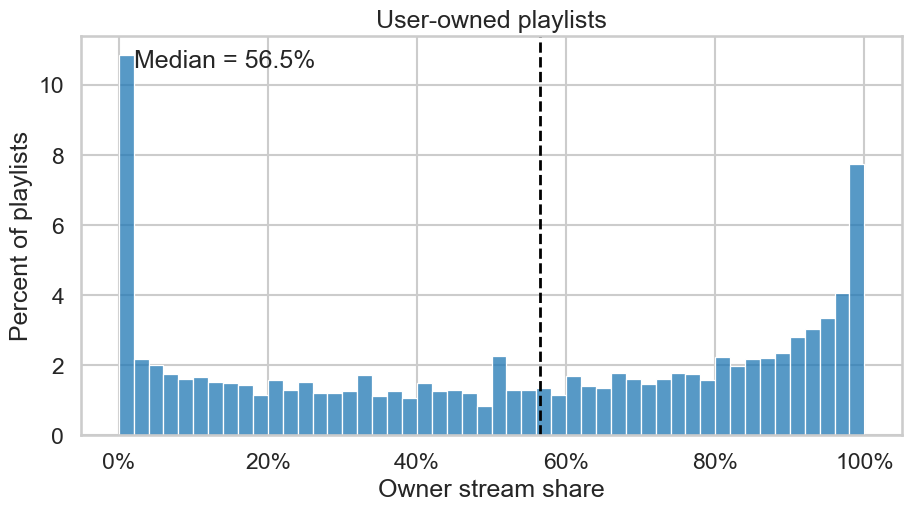

Saved Spotify-owned owner-share figure to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/spotify_owner_stream_share_distribution.png


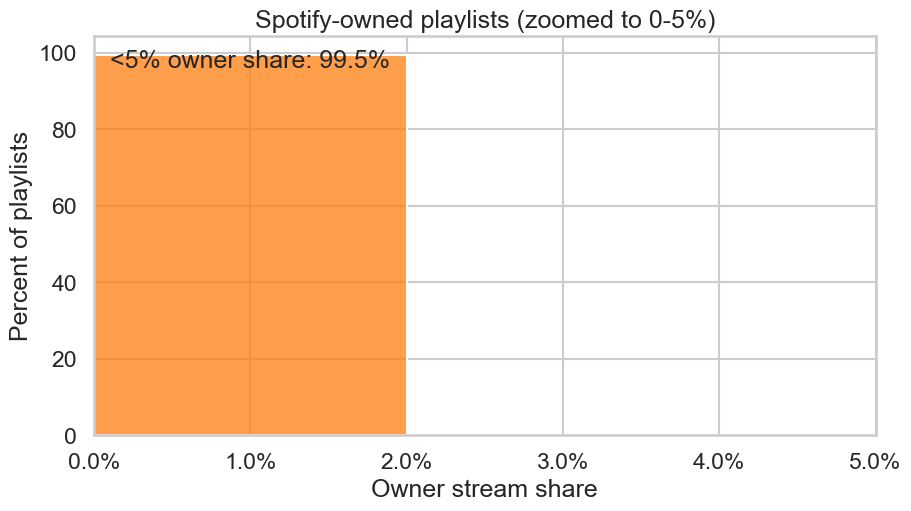

Saved >50% user-owned owner-share figure to /Users/joseeduardoo/projects/JobMarket/interview_prep/data_science_assignment/figures/user_owner_stream_share_distribution_gt50.png


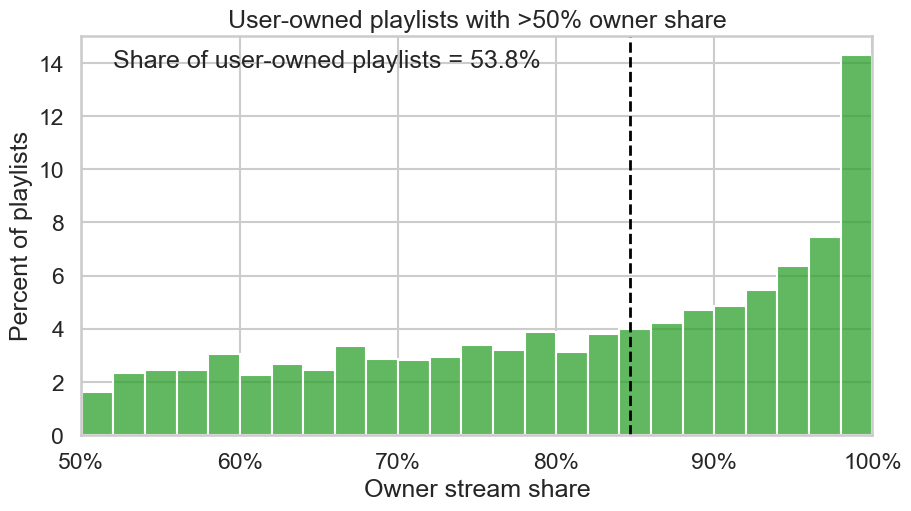

In [6]:
spotify_df = df[df["playlist_type"] == "Spotify-owned"].copy()
user_df = df[df["playlist_type"] == "User-owned"].copy()
user_gt50_df = user_df[user_df["owner_stream_share"] > 0.5].copy()

old_combined_plot_path = FIGURES_DIR / "owner_stream_share_distribution.png"
if old_combined_plot_path.exists():
    old_combined_plot_path.unlink()

fig_user, ax_user = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.histplot(
    user_df,
    x="owner_stream_share",
    bins=50,
    stat="percent",
    color="#1f77b4",
    ax=ax_user,
)
ax_user.axvline(user_df["owner_stream_share"].median(), color="black", linestyle="--", linewidth=2)
ax_user.set_title("User-owned playlists")
ax_user.set_xlabel("Owner stream share")
ax_user.set_ylabel("Percent of playlists")
ax_user.xaxis.set_major_formatter(PercentFormatter(1.0))
ax_user.text(0.02, ax_user.get_ylim()[1] * 0.92, f"Median = {user_df['owner_stream_share'].median():.1%}")

user_owner_share_plot_path = FIGURES_DIR / "user_owner_stream_share_distribution.png"
fig_user.savefig(user_owner_share_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved user-owned owner-share figure to {user_owner_share_plot_path}")
plt.show()

fig_spotify, ax_spotify = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.histplot(
    spotify_df,
    x="owner_stream_share",
    bins=25,
    stat="percent",
    color="#ff7f0e",
    ax=ax_spotify,
)
ax_spotify.set_xlim(0, 0.05)
ax_spotify.set_title("Spotify-owned playlists (zoomed to 0-5%)")
ax_spotify.set_xlabel("Owner stream share")
ax_spotify.set_ylabel("Percent of playlists")
ax_spotify.xaxis.set_major_formatter(PercentFormatter(1.0))
ax_spotify.text(0.001, ax_spotify.get_ylim()[1] * 0.92, f"<5% owner share: {(spotify_df['owner_stream_share'] < 0.05).mean():.1%}")

spotify_owner_share_plot_path = FIGURES_DIR / "spotify_owner_stream_share_distribution.png"
fig_spotify.savefig(spotify_owner_share_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved Spotify-owned owner-share figure to {spotify_owner_share_plot_path}")
plt.show()

fig_user_gt50, ax_user_gt50 = plt.subplots(figsize=(9, 5), constrained_layout=True)
sns.histplot(
    user_gt50_df,
    x="owner_stream_share",
    bins=25,
    stat="percent",
    color="#2ca02c",
    ax=ax_user_gt50,
)
ax_user_gt50.axvline(user_gt50_df["owner_stream_share"].median(), color="black", linestyle="--", linewidth=2)
ax_user_gt50.set_xlim(0.5, 1.0)
ax_user_gt50.set_title("User-owned playlists with >50% owner share")
ax_user_gt50.set_xlabel("Owner stream share")
ax_user_gt50.set_ylabel("Percent of playlists")
ax_user_gt50.xaxis.set_major_formatter(PercentFormatter(1.0))
ax_user_gt50.text(
    0.52,
    ax_user_gt50.get_ylim()[1] * 0.92,
    f"Share of user-owned playlists = {(user_df['owner_stream_share'] > 0.5).mean():.1%}",
)

user_owner_share_gt50_plot_path = FIGURES_DIR / "user_owner_stream_share_distribution_gt50.png"
fig_user_gt50.savefig(user_owner_share_gt50_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved >50% user-owned owner-share figure to {user_owner_share_gt50_plot_path}")
plt.show()


## Spotify-Owned Structural Feature Diagnostics

In [ ]:

spotify_structural_df = df.loc[df["playlist_type"] == "Spotify-owned"].copy()
spotify_structural_df["monthly_stream30s_per_mau"] = (
    spotify_structural_df["monthly_stream30s"] / spotify_structural_df["mau"].replace(0, np.nan)
)

SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR = FIGURES_DIR / "spotify_structural_feature_diagnostics"
SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR.mkdir(exist_ok=True)

spotify_structural_feature_specs = OrderedDict(
    (feature, structural_feature_specs[feature])
    for feature in ["n_tracks", "n_artists", "n_albums", "recent_track_change", "n_title_tokens"]
)

for metric_spec in success_metric_specs.values():
    (SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR / metric_spec["folder"]).mkdir(exist_ok=True)


def make_spotify_scatter_plot(data, feature, feature_label, metric, metric_spec, output_path):
    plot_data = data[[feature, metric]].dropna().copy()
    x = np.log1p(plot_data[feature])
    y = transform_series(plot_data[metric], metric_spec["y_transform"])

    can_fit = len(plot_data) >= 3 and plot_data[feature].nunique() >= 2
    if can_fit:
        slope, intercept = np.polyfit(x, y, 1)
        fitted = intercept + slope * x
        ss_res = np.sum((y - fitted) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        slope = np.nan
        intercept = np.nan
        r2 = np.nan

    spearman_rho = plot_data[[feature, metric]].corr(method="spearman").iloc[0, 1]

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    sns.regplot(
        x=x,
        y=y,
        ci=None,
        scatter_kws={"s": 45, "alpha": 0.7, "color": metric_spec["plot_color"]},
        line_kws={"color": "#d62728", "linewidth": 2.5},
        ax=ax,
    )
    ax.set_title(f"Spotify-owned playlists: {feature_label.lower()} vs {metric_spec['label'].lower()}")
    ax.set_xlabel(f"log(1 + {feature_label.lower()})")
    ax.set_ylabel(transformed_axis_label(metric_spec["label"], metric_spec["y_transform"]))
    if metric_spec["value_kind"] == "percent":
        ax.set_ylim(0, 1)
        apply_y_axis_format(ax, "percent")

    slope_text = f"{slope:.3f}" if pd.notna(slope) else "NA"
    r2_text = f"{r2:.3f}" if pd.notna(r2) else "NA"
    rho_text = f"{spearman_rho:.3f}" if pd.notna(spearman_rho) else "NA"
    ax.text(
        0.03,
        0.97,
        f"n = {len(plot_data):,}\nSlope = {slope_text}\n$R^2$ = {r2_text}\nSpearman = {rho_text}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="#c7c7c7"),
    )

    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    return {
        "n": int(len(plot_data)),
        "slope": float(slope) if pd.notna(slope) else np.nan,
        "intercept": float(intercept) if pd.notna(intercept) else np.nan,
        "r2": float(r2) if pd.notna(r2) else np.nan,
        "spearman_rho": float(spearman_rho) if pd.notna(spearman_rho) else np.nan,
    }


spotify_regression_rows = []
spotify_binned_rows = []
spotify_figure_rows = []

for feature, feature_spec in spotify_structural_feature_specs.items():
    for metric, metric_spec in success_metric_specs.items():
        metric_data = spotify_structural_df.loc[
            spotify_structural_df[[feature, metric]].notna().all(axis=1)
        ].copy()
        if metric_data.empty:
            continue

        metric_dir = SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR / metric_spec["folder"]
        scatter_path = metric_dir / f"{feature}__{metric}__scatter_log.png"
        binned_median_path = metric_dir / f"{feature}__{metric}__binned_median.png"
        binned_mean_path = metric_dir / f"{feature}__{metric}__binned_mean.png"

        regression_stats = make_spotify_scatter_plot(
            data=metric_data,
            feature=feature,
            feature_label=feature_spec["label"],
            metric=metric,
            metric_spec=metric_spec,
            output_path=scatter_path,
        )
        spotify_regression_rows.append(
            {
                "playlist_type": "Spotify-owned",
                "feature": feature,
                "feature_label": feature_spec["label"],
                "metric": metric,
                "metric_label": metric_spec["label"],
                **regression_stats,
            }
        )

        summary = build_binned_summary(metric_data, feature, feature_spec, metric)
        for _, row in summary.iterrows():
            spotify_binned_rows.append(
                {
                    "playlist_type": "Spotify-owned",
                    "feature": feature,
                    "feature_label": feature_spec["label"],
                    "metric": metric,
                    "metric_label": metric_spec["label"],
                    "feature_bin": row["feature_bin"],
                    "playlist_count": int(row["playlist_count"]),
                    "median_feature_value": row["median_feature_value"],
                    "median_value": row["median_value"],
                    "mean_value": row["mean_value"],
                }
            )

        make_binned_plot(
            summary=summary,
            feature_label=feature_spec["label"],
            metric_spec=metric_spec,
            stat="median",
            output_path=binned_median_path,
        )
        make_binned_plot(
            summary=summary,
            feature_label=feature_spec["label"],
            metric_spec=metric_spec,
            stat="mean",
            output_path=binned_mean_path,
        )

        spotify_figure_rows.extend(
            [
                {
                    "playlist_type": "Spotify-owned",
                    "feature": feature,
                    "metric": metric,
                    "plot_type": "scatter_log",
                    "path": str(scatter_path),
                },
                {
                    "playlist_type": "Spotify-owned",
                    "feature": feature,
                    "metric": metric,
                    "plot_type": "binned_median",
                    "path": str(binned_median_path),
                },
                {
                    "playlist_type": "Spotify-owned",
                    "feature": feature,
                    "metric": metric,
                    "plot_type": "binned_mean",
                    "path": str(binned_mean_path),
                },
            ]
        )

spotify_regression_summary_df = pd.DataFrame(spotify_regression_rows)
spotify_binned_summary_df = pd.DataFrame(spotify_binned_rows)
spotify_figure_index_df = pd.DataFrame(spotify_figure_rows)

spotify_regression_summary_path = SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR / "spotify_structural_feature_regression_summary.csv"
spotify_binned_summary_path = SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR / "spotify_structural_feature_binned_summary.csv"
spotify_figure_index_path = SPOTIFY_STRUCTURAL_DIAGNOSTICS_DIR / "spotify_structural_feature_figure_index.csv"

spotify_regression_summary_df.to_csv(spotify_regression_summary_path, index=False)
spotify_binned_summary_df.to_csv(spotify_binned_summary_path, index=False)
spotify_figure_index_df.to_csv(spotify_figure_index_path, index=False)

print(f"Saved Spotify structural regression summary to {spotify_regression_summary_path}")
print(f"Saved Spotify structural binned summary to {spotify_binned_summary_path}")
print(f"Saved Spotify structural figure index to {spotify_figure_index_path}")

spotify_regression_summary_df


## Spotify-Owned Genre Analysis

In [ ]:

SPOTIFY_MIN_CONTENT_PLAYLISTS = 5
SPOTIFY_TOP_CONTENT_GROUPS_TO_SHOW = 10

spotify_content_df = df.loc[df["playlist_type"] == "Spotify-owned"].copy()
spotify_content_df["success_top_decile_non_owner"] = (
    spotify_content_df["non_owner_monthly_stream30s"] >= spotify_content_df["non_owner_monthly_stream30s"].quantile(0.90)
).astype(int)
spotify_overall_success_rate = spotify_content_df["success_top_decile_non_owner"].mean()


def summarize_spotify_content_dimension(data, dimension_col, min_playlists=5):
    summary_df = (
        data.loc[data[dimension_col].notna()]
        .groupby(dimension_col, observed=False)
        .agg(
            playlist_count=("playlist_uri", "size"),
            median_non_owner_monthly_stream30s=("non_owner_monthly_stream30s", "median"),
            success_rate=("success_top_decile_non_owner", "mean"),
            median_owner_stream_share=("owner_stream_share", "median"),
        )
        .reset_index()
        .rename(columns={dimension_col: "content_label"})
    )
    summary_df["pct_of_spotify_owned_playlists"] = summary_df["playlist_count"] / len(data)
    summary_df["success_rate_lift"] = summary_df["success_rate"] / spotify_overall_success_rate
    summary_df = summary_df.sort_values(
        ["median_non_owner_monthly_stream30s", "success_rate_lift"],
        ascending=[False, False],
    ).reset_index(drop=True)
    filtered_summary_df = summary_df.loc[summary_df["playlist_count"] >= min_playlists].copy()
    return summary_df, filtered_summary_df


spotify_genre_summary_df, filtered_spotify_genre_summary_df = summarize_spotify_content_dimension(
    spotify_content_df,
    dimension_col="genre_1",
    min_playlists=SPOTIFY_MIN_CONTENT_PLAYLISTS,
)

spotify_genre_summary_path = FIGURES_DIR / "genre_summary_spotify_owned.csv"
filtered_spotify_genre_summary_path = FIGURES_DIR / "genre_summary_spotify_owned_filtered.csv"
spotify_genre_summary_df.to_csv(spotify_genre_summary_path, index=False)
filtered_spotify_genre_summary_df.to_csv(filtered_spotify_genre_summary_path, index=False)

spotify_genre_median_top_df = filtered_spotify_genre_summary_df.nlargest(
    SPOTIFY_TOP_CONTENT_GROUPS_TO_SHOW, "median_non_owner_monthly_stream30s"
).sort_values("median_non_owner_monthly_stream30s", ascending=True)
spotify_genre_lift_top_df = filtered_spotify_genre_summary_df.nlargest(
    SPOTIFY_TOP_CONTENT_GROUPS_TO_SHOW, "success_rate_lift"
).sort_values("success_rate_lift", ascending=True)

spotify_genre_median_plot_path = FIGURES_DIR / "genre_median_non_owner_streams_spotify_owned.png"
spotify_genre_lift_plot_path = FIGURES_DIR / "genre_top_decile_lift_spotify_owned.png"

save_content_barplot(
    plot_df=spotify_genre_median_top_df,
    x_col="median_non_owner_monthly_stream30s",
    y_col="content_label",
    color="#4c78a8",
    title="Genre_1: typical broad reach in Spotify-owned playlists",
    xlabel="Median non-owner monthly 30s streams",
    output_path=spotify_genre_median_plot_path,
    label_fmt=lambda v: f"{v:,.0f}",
)

save_content_barplot(
    plot_df=spotify_genre_lift_top_df,
    x_col="success_rate_lift",
    y_col="content_label",
    color="#f58518",
    title="Genre_1: over-indexing in top-decile success (Spotify-owned)",
    xlabel="Success-rate lift vs. Spotify-owned baseline",
    output_path=spotify_genre_lift_plot_path,
    label_fmt=lambda v: f"{v:.2f}x",
    add_reference_line=True,
)

print(f"Saved Spotify genre summary to {spotify_genre_summary_path}")
print(f"Saved filtered Spotify genre summary to {filtered_spotify_genre_summary_path}")
print(f"Saved Spotify genre median plot to {spotify_genre_median_plot_path}")
print(f"Saved Spotify genre lift plot to {spotify_genre_lift_plot_path}")
print(f"Overall Spotify-owned top-decile success rate: {spotify_overall_success_rate:.2%}")

display(filtered_spotify_genre_summary_df.sort_values("median_non_owner_monthly_stream30s", ascending=False).head(15))
display(filtered_spotify_genre_summary_df.sort_values("success_rate_lift", ascending=False).head(15))


## Spotify-Owned Mood Analysis

In [ ]:

spotify_mood_summary_df, filtered_spotify_mood_summary_df = summarize_spotify_content_dimension(
    spotify_content_df,
    dimension_col="mood_1",
    min_playlists=SPOTIFY_MIN_CONTENT_PLAYLISTS,
)

spotify_mood_summary_path = FIGURES_DIR / "mood_summary_spotify_owned.csv"
filtered_spotify_mood_summary_path = FIGURES_DIR / "mood_summary_spotify_owned_filtered.csv"
spotify_mood_summary_df.to_csv(spotify_mood_summary_path, index=False)
filtered_spotify_mood_summary_df.to_csv(filtered_spotify_mood_summary_path, index=False)

spotify_mood_median_top_df = filtered_spotify_mood_summary_df.nlargest(
    SPOTIFY_TOP_CONTENT_GROUPS_TO_SHOW, "median_non_owner_monthly_stream30s"
).sort_values("median_non_owner_monthly_stream30s", ascending=True)
spotify_mood_lift_top_df = filtered_spotify_mood_summary_df.nlargest(
    SPOTIFY_TOP_CONTENT_GROUPS_TO_SHOW, "success_rate_lift"
).sort_values("success_rate_lift", ascending=True)

spotify_mood_median_plot_path = FIGURES_DIR / "mood_median_non_owner_streams_spotify_owned.png"
spotify_mood_lift_plot_path = FIGURES_DIR / "mood_top_decile_lift_spotify_owned.png"

save_content_barplot(
    plot_df=spotify_mood_median_top_df,
    x_col="median_non_owner_monthly_stream30s",
    y_col="content_label",
    color="#72b7b2",
    title="Mood_1: typical broad reach in Spotify-owned playlists",
    xlabel="Median non-owner monthly 30s streams",
    output_path=spotify_mood_median_plot_path,
    label_fmt=lambda v: f"{v:,.0f}",
)

save_content_barplot(
    plot_df=spotify_mood_lift_top_df,
    x_col="success_rate_lift",
    y_col="content_label",
    color="#e45756",
    title="Mood_1: over-indexing in top-decile success (Spotify-owned)",
    xlabel="Success-rate lift vs. Spotify-owned baseline",
    output_path=spotify_mood_lift_plot_path,
    label_fmt=lambda v: f"{v:.2f}x",
    add_reference_line=True,
)

print(f"Saved Spotify mood summary to {spotify_mood_summary_path}")
print(f"Saved filtered Spotify mood summary to {filtered_spotify_mood_summary_path}")
print(f"Saved Spotify mood median plot to {spotify_mood_median_plot_path}")
print(f"Saved Spotify mood lift plot to {spotify_mood_lift_plot_path}")

display(filtered_spotify_mood_summary_df.sort_values("median_non_owner_monthly_stream30s", ascending=False).head(15))
display(filtered_spotify_mood_summary_df.sort_values("success_rate_lift", ascending=False).head(15))
